# 01 - Data Overview
Dataset : Kaggle Fraud Detection (Kartik) — `fraudTrain.csv` + `fraudTest.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT = Path('c:/Users/hp/Desktop/fraude_detection/fraud-detection/analytics')
FIGURES = ROOT / 'notebooks/outputs/figures'
FIGURES.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(ROOT / 'data/raw/fraudTrain.csv')
test  = pd.read_csv(ROOT / 'data/raw/fraudTest.csv')
df    = pd.concat([train, test], ignore_index=True)

# Parsing datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour']        = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month']       = df['trans_date_trans_time'].dt.month

# Distance domicile -> commerçant (formule haversine simplifiée)
df['distance'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2) * 111

print(f'Shape total : {df.shape}')
df.head(3)

Shape total : (1852394, 27)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,month,distance
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,96.884075
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,30.226415
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,108.318831


## 1. Types de données et valeurs manquantes

In [2]:
print('=== TYPES ===')
print(df.dtypes)
print('\n=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
display(missing[missing > 0].to_frame('count'))

=== TYPES ===
Unnamed: 0                        int64
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                              object
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
hour                              int32
day_of_week               

,count


## 2. Statistiques descriptives

In [3]:
display(df[['amt', 'distance', 'city_pop', 'is_fraud']].describe().round(2))

fraud_rate = df['is_fraud'].mean() * 100
n_fraud    = df['is_fraud'].sum()
print(f'\nTaux de fraude : {fraud_rate:.3f}%')
print(f'Fraudes        : {n_fraud:,} / {len(df):,}')

,amt,distance,city_pop,is_fraud
count,1852394.00,1852394.00,1852394.00,1852394.00
mean,70.06,84.98,88643.67,0.01
std,159.25,31.61,301487.62,0.07
min,1.00,0.03,23.00,0.00
25%,9.64,62.69,741.00,0.00
50%,47.45,88.61,2443.00,0.00
75%,83.10,108.49,20328.00,0.00
max,28948.90,156.88,2906700.00,1.00



Taux de fraude : 0.521%
Fraudes        : 9,651 / 1,852,394


## 3. Distribution des montants (fraude vs normal)

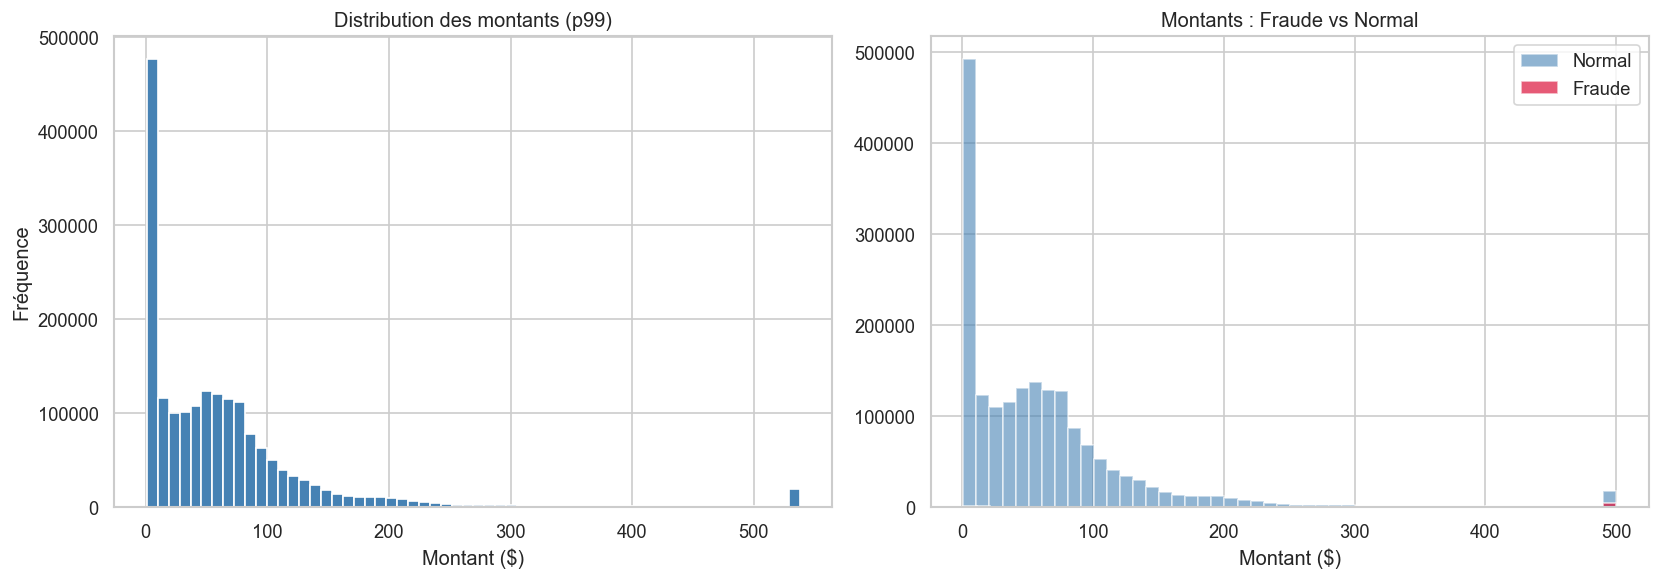

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
df['amt'].clip(upper=df['amt'].quantile(0.99)).hist(
    ax=axes[0], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des montants (p99)')
axes[0].set_xlabel('Montant ($)')
axes[0].set_ylabel('Fréquence')

# Fraude vs Normal
df[df['is_fraud']==0]['amt'].clip(upper=500).hist(
    ax=axes[1], bins=50, alpha=0.6, label='Normal', color='steelblue')
df[df['is_fraud']==1]['amt'].clip(upper=500).hist(
    ax=axes[1], bins=50, alpha=0.7, label='Fraude', color='crimson')
axes[1].set_title('Montants : Fraude vs Normal')
axes[1].set_xlabel('Montant ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'distribution_amount.png', bbox_inches='tight')
plt.show()

## 4. Fraudes par heure et par jour

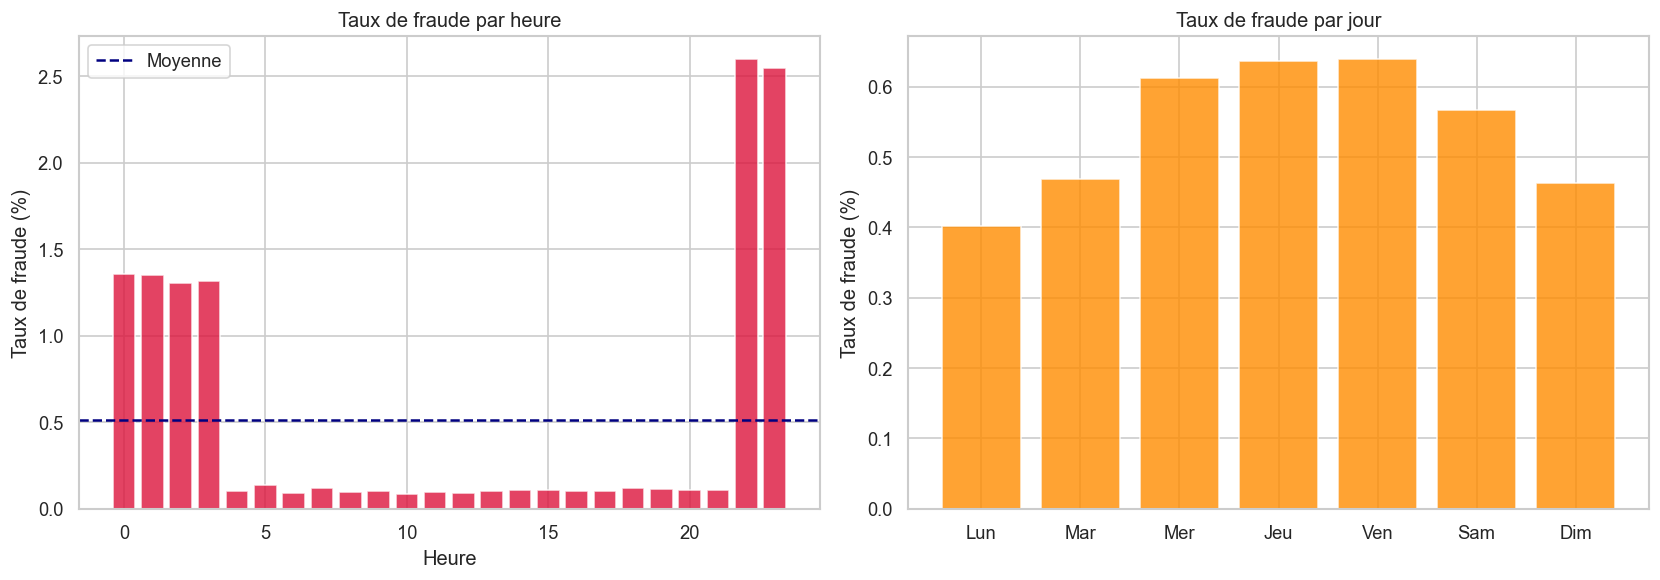

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='crimson', alpha=0.8)
axes[0].axhline(fraud_by_hour.mean(), color='navy', linestyle='--', label='Moyenne')
axes[0].set_title('Taux de fraude par heure')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Taux de fraude (%)')
axes[0].legend()

days = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
fraud_by_day = df.groupby('day_of_week')['is_fraud'].mean() * 100
axes[1].bar(days, fraud_by_day.values, color='darkorange', alpha=0.8)
axes[1].set_title('Taux de fraude par jour')
axes[1].set_ylabel('Taux de fraude (%)')

plt.tight_layout()
plt.savefig(FIGURES / 'fraud_by_hour.png', bbox_inches='tight')
plt.show()

## 5. Top 10 commerçants et fraudes par catégorie

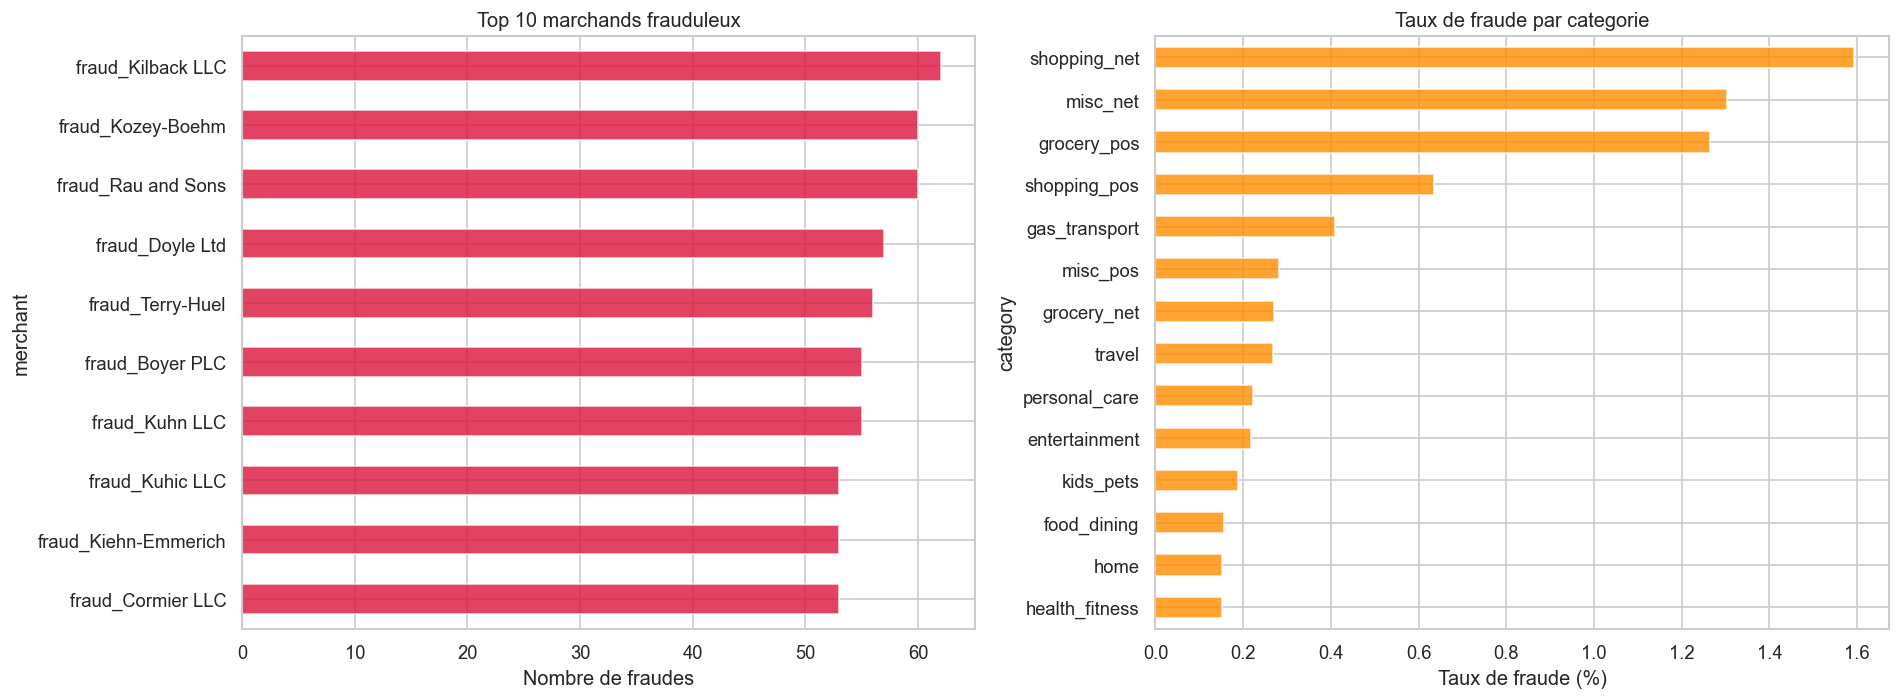

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_merchants = df[df['is_fraud']==1].groupby('merchant')['is_fraud'].count().sort_values(ascending=False).head(10)
top_merchants.plot(kind='barh', ax=axes[0], color='crimson', alpha=0.8)
axes[0].set_title('Top 10 marchands frauduleux')
axes[0].set_xlabel('Nombre de fraudes')
axes[0].invert_yaxis()

fraud_by_cat = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
fraud_by_cat.plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('Taux de fraude par categorie')
axes[1].set_xlabel('Taux de fraude (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / 'top_merchants.png', bbox_inches='tight')
plt.show()

## 6. Matrice de corrélation

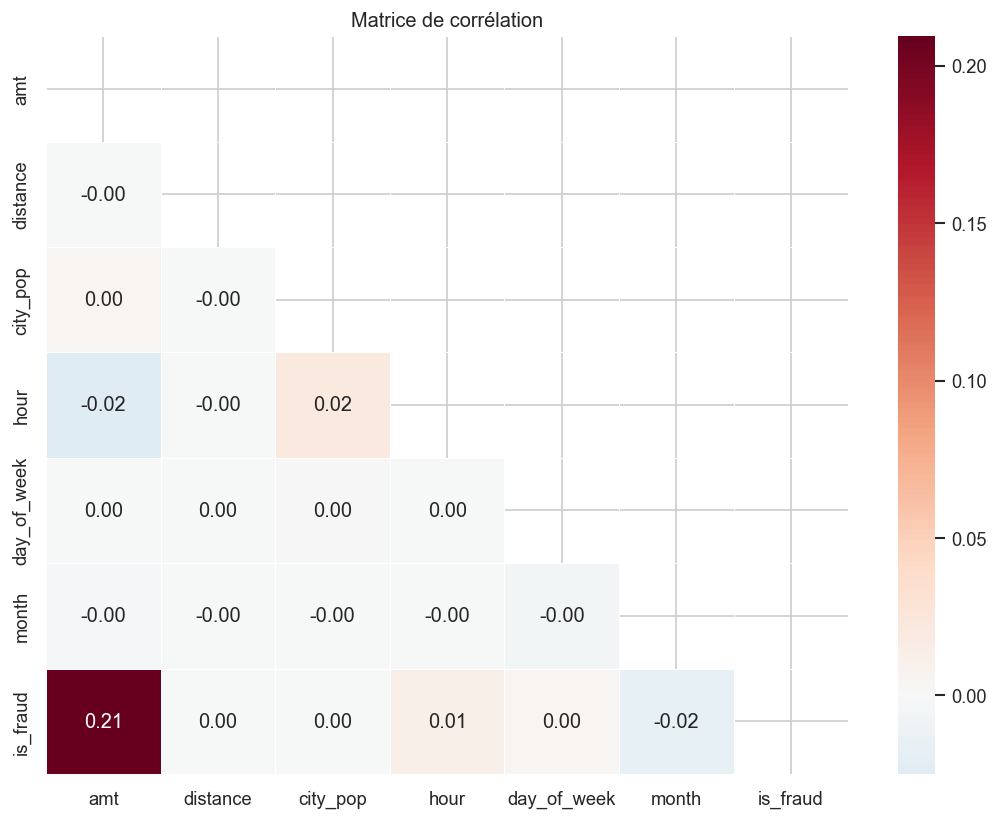

In [7]:
num_cols = ['amt', 'distance', 'city_pop', 'hour', 'day_of_week', 'month', 'is_fraud']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_matrix.png', bbox_inches='tight')
plt.show()

## 7. Conclusion

**Features discriminantes identifiées :**
- `amt` : distribution très différente entre fraude et normal
- `hour` : pics de fraude la nuit (22h-4h)
- `distance` : fraudes géographiquement plus distantes
- `category` : certaines catégories très risquées
- `city_pop` : les fraudes surviennent plus dans les petites villes

→ Détails complets dans `src/features/feature_list.txt`